# M5 Forecasting Competition EDA

This notebook explores key ideas for understanding the M5 Forecasting Competition data, which will help in crafting a Chronos-2 zero-shot baseline.

In [1]:
import pandas as pd
import os, gc, numpy as np, pyarrow.parquet as pq


In [2]:
import resource

# Set max memory to 4GB (in bytes)
limit = 29 * 1024 * 1024 * 1024  # 4 GB
resource.setrlimit(resource.RLIMIT_AS, (limit, limit))

In [3]:
DATA_TAG = "sales_only"

DATA_PATH  = "/mnt/lab/datasets/M5/jointed_M5.parquet"

CUTOFF_DAY = "2016-05-22"  
CUTOFF_DAY = pd.to_datetime(CUTOFF_DAY) - pd.Timedelta(days=28)
CUTOFF_DAY = CUTOFF_DAY.strftime("%Y-%m-%d")    
print(f"Cutoff day: {CUTOFF_DAY}")


Cutoff day: 2016-04-24


In [ ]:
# ── Reuse the same M5DataPipeline class from the benchmarks notebook ──────────
import os, numpy as np, pyarrow.parquet as pq

class M5DataPipeline:
    """Unchanged from m5_run_benchmarks.ipynb — do not edit here."""
    def __init__(self, config, target_col="sales_quantity"):
        self.target = target_col
        self.date   = "date"
        self.id     = "id"
        self.base_dir   = "/mnt/lab/nmwamsojo/prepared_data"
        self.tag        = config.get("tag", "default")
        self.model_tag  = config.get("model_tag", "default_model")
        self.level_map  = {
            1: [], 2: ["state_id"], 3: ["store_id"], 4: ["cat_id"], 5: ["dept_id"],
            6: ["state_id", "cat_id"], 7: ["state_id", "dept_id"],
            8: ["store_id", "cat_id"], 9: ["store_id", "dept_id"],
            10: ["item_id"], 11: ["state_id", "item_id"], 12: ["id"]
        }
        self.covariates  = ["wm_yr_wk", "wday", "month", "year",
                            "event_name_1", "event_type_1",
                            "snap_CA", "snap_TX", "snap_WI", "sell_price"]
        self.static_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

    def _get_base_folder(self, cutoff_day, level):
        return os.path.join(self.base_dir, self.tag,
                            f"level_{level}", cutoff_day.replace("-", ""))

    def _get_cache_paths(self, cutoff_day, level):
        folder = self._get_base_folder(cutoff_day, level)
        return {"folder": folder,
                "hist":   os.path.join(folder, "hist.parquet"),
                "future": os.path.join(folder, "future.parquet"),
                "static": os.path.join(folder, "static.parquet")}
    
    def optimize_dtypes(self, df):
        # Sales are always small integers in M5
        if "sales_quantity" in df.columns:
            df["sales_quantity"] = pd.to_numeric(df["sales_quantity"], downcast="float")
        # Prices and SNAP flags
        for col in df.select_dtypes(include=['float64']).columns:
            df[col] = pd.to_numeric(df[col], downcast="float")
        for col in df.select_dtypes(include=['int64']).columns:
            df[col] = pd.to_numeric(df[col], downcast="integer")
        
        if "id" in df.columns:
            df["id"] = df["id"].astype("category")
        return df
    
    def get_forecast_paths(self, cutoff_day, level, model_tag=None):
        m_tag  = model_tag or self.model_tag
        folder = os.path.join(self._get_base_folder(cutoff_day, level), "models", m_tag)
        return {"folder":   folder,
                "forecast": os.path.join(folder, "forecasts.parquet"),
                "metrics":  os.path.join(folder, "metrics.json")}

    def prepare(self, path, cutoff_day, level=12):
        print(f"--- Loading: {path} ---")
        aggr_cols = self.level_map[level]
        schema_names    = set(pq.read_schema(path).names)
        target_on_disk  = "sold" if "sold" in schema_names else self.target
        needed = ({self.id, self.date, target_on_disk}
                  | (set(aggr_cols)        & schema_names)
                  | (set(self.covariates)  & schema_names)
                  | (set(self.static_cols) & schema_names))
        df = pd.read_parquet(path, columns=list(needed))
        if target_on_disk != self.target:
            df.rename(columns={target_on_disk: self.target}, inplace=True)
        df[self.date] = pd.to_datetime(df[self.date], utc=False, cache=True)
        for col in [c for c in df.columns if "event" in c]:
            if hasattr(df[col], "cat"):
                if "none" not in df[col].cat.categories:
                    df[col] = df[col].cat.add_categories("none")
                df[col] = df[col].fillna("none")
            else:
                df[col] = df[col].fillna("none").astype("category")
        type_map = {"snap": np.int8, "wday": np.int8, "month": np.int8,
                    "year": np.int16, "wm_yr_wk": np.int16,
                    "sell_price": np.float32, self.target: np.float32}
        for col, dtype in type_map.items():
            for c in [c for c in df.columns if col in c]:
                df[c] = df[c].astype(dtype)
        for col in aggr_cols + self.static_cols:
            if col in df.columns and df[col].dtype == object:
                df[col] = df[col].astype("category")
        print(f"--- Aggregating to Level {level} ---")
        agg_map = {self.target: "sum"}
        for col in self.covariates:
            if col in df.columns:
                if "snap" in col:   agg_map[col] = "max"
                elif "event" in col: agg_map[col] = "first"
                else:               agg_map[col] = "mean"
        for col in self.static_cols:
            if col in df.columns and col not in aggr_cols:
                agg_map[col] = "first"
        df_aggr = (df.groupby(aggr_cols + [self.date], observed=True, sort=False)
                     .agg(agg_map).reset_index())
        del df
        gc.collect()
        
        if len(aggr_cols) == 0:
            df_aggr[self.id] = "All"
        elif len(aggr_cols) == 1:
            df_aggr[self.id] = df_aggr[aggr_cols[0]].astype(str)
        else:
            def _get_str_vals(s):
                if hasattr(s, "cat"):
                    return s.cat.categories.astype(str).values[s.cat.codes.values]
                return s.astype(str).values
            parts = [_get_str_vals(df_aggr[c]) for c in aggr_cols]
            ids   = parts[0]
            for part in parts[1:]:
                ids = np.char.add(np.char.add(ids, "_"), part)
            df_aggr[self.id] = ids
        df_aggr[self.id] = (df_aggr[self.id]
                             .astype(str)
                             .str.replace("_evaluation", "", regex=False)
                             .astype("category"))
        cutoff = pd.Timestamp(cutoff_day)

        df_aggr['id'] = df_aggr['id'].astype(str)

        df_aggr = df_aggr.sort_values([self.id, self.date]).reset_index(drop=True)
        mask    = df_aggr[self.date] <= cutoff
        hist_df   = df_aggr[mask].copy()
        future_df = df_aggr[~mask].copy()
        if self.target in future_df.columns:
            future_df.drop(columns=[self.target], inplace=True)
        static_present = [c for c in self.static_cols if c in df_aggr.columns]
        static_df = (df_aggr[[self.id] + static_present]
                       .drop_duplicates().reset_index(drop=True))
        print(f"Done. {df_aggr[self.id].nunique():,} series | "
              f"Hist: {len(hist_df):,} rows | Future: {len(future_df):,} rows")
        del df_aggr
        gc.collect()

        return hist_df, future_df, static_df

    def trim_series_to_active(self, df, id_col="id", target_col="sales_quantity"):
        first_active = (
            df[df[target_col] > 0]
            .groupby(self.id, observed=True)["date"]
            .min()
            .rename("_first_active")
        )
        df = df.merge(first_active, on=self.id, how="left")
        df = df[df["date"] >= df["_first_active"]].drop(columns="_first_active")
        return df.reset_index(drop=True)

    @staticmethod
    def _compute_scales(array: np.ndarray) -> np.ndarray:
        """RMSSE scale denominator: mean(diff(active)^2) per row."""
        n      = array.shape[0]
        scales = np.empty(n, dtype=np.float64)
        for i in range(n):
            row = array[i]
            nz  = np.flatnonzero(row)
            if len(nz) < 2:
                scales[i] = 1e-8
                continue
            active = row[nz[0]:]
            if len(active) < 2:
                scales[i] = 1e-8
                continue
            d = np.diff(active)
            scales[i] = float(np.mean(d * d))
        return np.maximum(scales, 1e-8)

    def _build_weights_scales(self, hist_df, hist_df_trimmed, static_df):
        """
        Compute per-level RMSSE scales and revenue weights for all 12 hierarchy levels.
        Mirrors M5Evaluator._build_hierarchy:
          - Scales: raw wide matrix for L1-L11, trimmed for L12.
          - Weights: last-28-day revenue (trimmed * sell_price), normalised.
        Returns DataFrame [level, id, scale, weight].
        """
        raw_df     = hist_df.copy()
        trimmed_df = hist_df_trimmed.copy()
        raw_df["id"]     = raw_df["id"].astype(str)
        trimmed_df["id"] = trimmed_df["id"].astype(str)

        raw_wide = (
            raw_df.pivot(index="id", columns="date", values=self.target)
                  .fillna(0).sort_index(axis=1)
        )
        trimmed_wide = (
            trimmed_df.pivot(index="id", columns="date", values=self.target)
                      .fillna(0).sort_index(axis=1)
        )

        price_col = "sell_price"
        if price_col in trimmed_df.columns:
            price_wide = (
                trimmed_df.pivot(index="id", columns="date", values=price_col)
                          .reindex(index=trimmed_wide.index, columns=trimmed_wide.columns)
            )
            price_wide   = price_wide.ffill(axis=1).bfill(axis=1).fillna(1.0)
            revenue_wide = trimmed_wide * price_wide
            del price_wide
        else:
            revenue_wide = trimmed_wide.copy()

        _static   = static_df.set_index("id").copy()
        _static.index = _static.index.astype(str)
        hier_cols = [c for c in ["state_id", "store_id", "cat_id", "dept_id", "item_id"]
                     if c in _static.columns]

        raw_joined     = raw_wide.join(_static[hier_cols])
        trimmed_joined = trimmed_wide.join(_static[hier_cols])
        rev_joined     = revenue_wide.join(_static[hier_cols])

        raw_date_cols     = list(raw_wide.columns)
        trimmed_date_cols = list(trimmed_wide.columns)
        del raw_wide, trimmed_wide, revenue_wide, raw_df, trimmed_df
        gc.collect()

        records = []
        for lvl, cols in self.level_map.items():
            if lvl == 12:
                agg_scale = (trimmed_joined.groupby(cols, observed=True)[trimmed_date_cols].sum()
                             if cols else trimmed_joined[trimmed_date_cols].sum().to_frame().T)
            else:
                agg_scale = (raw_joined.groupby(cols, observed=True)[raw_date_cols].sum()
                             if cols else raw_joined[raw_date_cols].sum().to_frame().T)

            rev_agg = (rev_joined.groupby(cols, observed=True)[trimmed_date_cols].sum()
                       if cols else rev_joined[trimmed_date_cols].sum().to_frame().T)

            scales  = self._compute_scales(agg_scale.values.astype(np.float64))
            w_vals  = rev_agg.values[:, -28:].sum(axis=1)
            w_sum   = w_vals.sum()
            weights = w_vals / w_sum if w_sum > 0 else np.ones(len(w_vals)) / len(w_vals)

            if not cols:
                ids = ["All"]
            elif len(cols) == 1:
                ids = agg_scale.index.astype(str).tolist()
            else:
                ids = ["_".join(str(v) for v in idx) for idx in agg_scale.index]

            for i, id_ in enumerate(ids):
                records.append({"level": lvl, "id": id_,
                                "scale": float(scales[i]), "weight": float(weights[i])})
            print(f"    Level {lvl:>2}: {len(ids):,} series", flush=True)

        del raw_joined, trimmed_joined, rev_joined
        gc.collect()
        return pd.DataFrame(records)

    def get_prepared_data(self, path, cutoff_day, level=12, force_reprepare=False):
        paths    = self._get_cache_paths(cutoff_day, level)
        hist_trimmed_path   = paths["hist"].replace("hist", "hist_trimmed")
        weights_scales_path = paths["hist"].replace("hist", "weights_scales")
        use_cache = (os.path.exists(paths["hist"])
                     and os.path.exists(hist_trimmed_path)
                     and os.path.exists(weights_scales_path)
                     and not force_reprepare)
        if use_cache:
            print(f"--- Cache Hit: Data found in {paths['folder']} ---")
            return (pd.read_parquet(paths["hist"]),
                    pd.read_parquet(hist_trimmed_path),
                    pd.read_parquet(paths["future"]),
                    pd.read_parquet(paths["static"]),
                    pd.read_parquet(weights_scales_path))
        reason = "Force Reprepare" if force_reprepare else "Cache Miss"
        print(f"--- {reason}: Preparing Level {level} for {cutoff_day} ---")
        hist_df, future_df, static_df = self.prepare(path, cutoff_day, level)
        hist_df_trimmed = self.trim_series_to_active(hist_df, id_col="id", target_col="sales_quantity")
        print("  Building weights & scales …", flush=True)
        weights_scales  = self._build_weights_scales(hist_df, hist_df_trimmed, static_df)
        os.makedirs(paths["folder"], exist_ok=True)
        hist_df.to_parquet(paths["hist"],              index=False)
        hist_df_trimmed.to_parquet(hist_trimmed_path,  index=False)
        future_df.to_parquet(paths["future"],          index=False)
        static_df.to_parquet(paths["static"],          index=False)
        weights_scales.to_parquet(weights_scales_path, index=False)
        return hist_df, hist_df_trimmed, future_df, static_df, weights_scales

dataprep_config = {"tag": DATA_TAG,
                   "base_cols": ['id', 'date', 'sales_quantity'],
                   "extra_cols": []
                }
pipeline = M5DataPipeline(config=dataprep_config)
hist_df, hist_df_trimmed, future_df, static_df, weights_scales = pipeline.get_prepared_data(DATA_PATH, CUTOFF_DAY, level=12, force_reprepare=True)

print(f"\nhist_df         : {hist_df.shape}  (columns: {list(hist_df.columns)})")
print(f"hist_df_trimmed : {hist_df_trimmed.shape}")
print(f"future_df       : {future_df.shape}  (columns: {list(future_df.columns)})")
print(f"static_df       : {static_df.shape}")
print(f"weights_scales  : {weights_scales.shape}  levels: {sorted(weights_scales['level'].unique())}")

del pipeline
gc.collect()

--- Cache Hit: Data found in /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424 ---



hist_df         : (58327370, 18)  (columns: ['id', 'date', 'sales_quantity', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])
hist_df_trimmed : (45942500, 18)
future_df       : (853720, 17)  (columns: ['id', 'date', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])
static_df       : (30490, 6)


0

In [5]:
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)

# ── Per-series stats ───────────────────────────────────────────────────────────
grp = hist_df.groupby("id", observed=True)

raw_len   = grp["date"].count().rename("raw_length")
zero_frac = (
    grp["sales_quantity"]
    .apply(lambda s: (s == 0).mean())
    .rename("zero_frac")
)

nonzero_rows = hist_df[hist_df["sales_quantity"] > 0]
first_sale   = nonzero_rows.groupby("id", observed=True)["date"].min().rename("first_sale_date")
last_date    = grp["date"].max().rename("last_date")
active_len   = (last_date - first_sale).dt.days.add(1).rename("active_length")

series_stats = pd.concat([raw_len, zero_frac, first_sale, last_date, active_len], axis=1)
series_stats = series_stats.join(
    static_df.set_index("id")[["dept_id", "cat_id", "store_id", "state_id"]],
    how="left",
)

print(f"Series stats computed for {len(series_stats):,} series.")
display(series_stats[["raw_length", "active_length", "zero_frac"]].describe().round(1))

Series stats computed for 30,490 series.


,raw_length,active_length,zero_frac
count,30490.0,30490.0,30490.0
mean,1913.0,1506.8,0.7
std,0.0,477.2,0.2
min,1913.0,68.0,0.0
25%,1913.0,1147.0,0.5
50%,1913.0,1754.0,0.7
75%,1913.0,1912.0,0.9
max,1913.0,1913.0,1.0


## Time Series Distribution & Key EDA Plots

Covers: raw vs. active series length, first-sale date, zero-sales sparsity, sales quantity distribution, day-of-week seasonality, and hierarchical breakdowns (category / department / store).

/mnt/lab/nmwamsojo/uv_workspace/tmp/ipykernel_2814574/1978571533.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_zero = (series_stats.groupby("dept_id")["zero_frac"]
/mnt/lab/nmwamsojo/uv_workspace/tmp/ipykernel_2814574/1978571533.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_len = (series_stats.groupby("store_id")["active_length"]


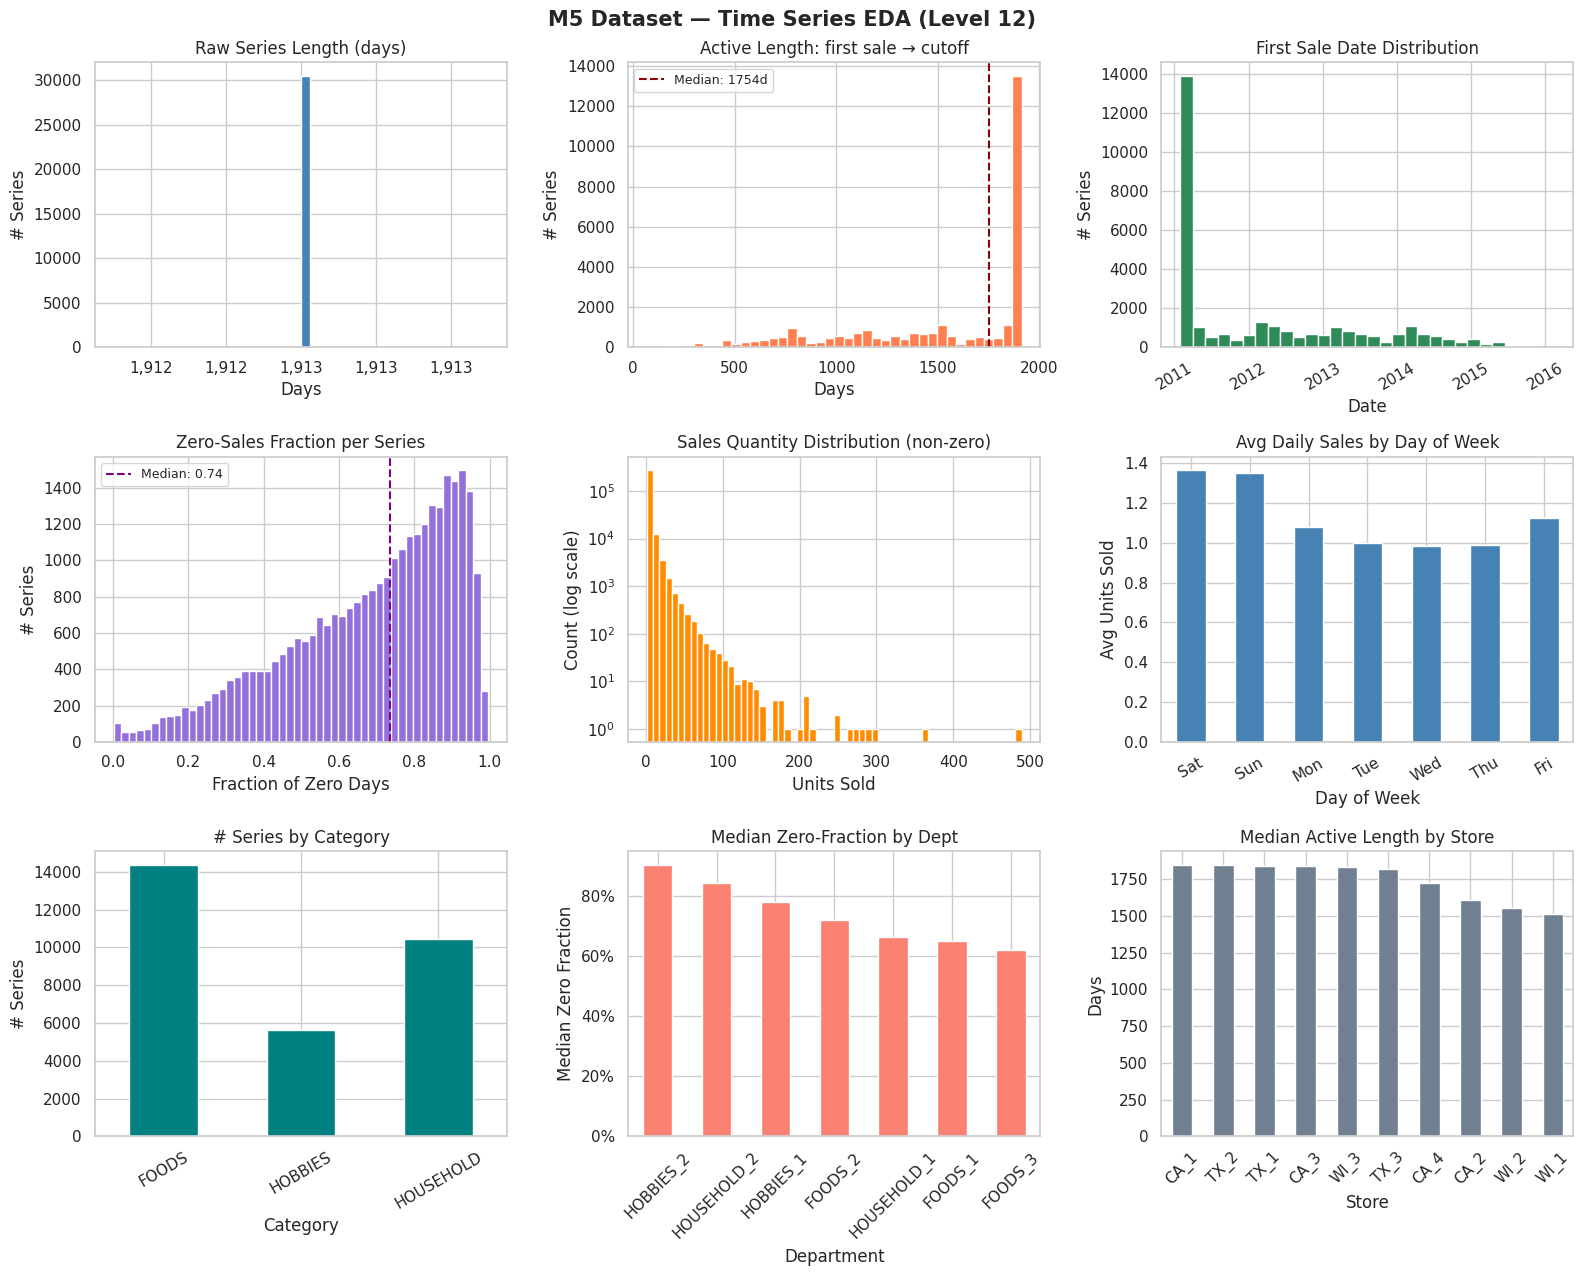

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("M5 Dataset — Time Series EDA (Level 12)", fontsize=15, fontweight="bold")

# ── [0,0] Raw length distribution ─────────────────────────────────────────────
ax = axes[0, 0]
series_stats["raw_length"].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Raw Series Length (days)")
ax.set_xlabel("Days")
ax.set_ylabel("# Series")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── [0,1] Active length (first sale → cutoff) ─────────────────────────────────
ax = axes[0, 1]
al = series_stats["active_length"].dropna()
al.hist(bins=40, ax=ax, color="coral", edgecolor="white")
ax.set_title("Active Length: first sale → cutoff")
ax.set_xlabel("Days")
ax.set_ylabel("# Series")
med = al.median()
ax.axvline(med, color="darkred", linestyle="--", linewidth=1.5, label=f"Median: {med:.0f}d")
ax.legend(fontsize=9)

# ── [0,2] First-sale date distribution ────────────────────────────────────────
ax = axes[0, 2]
series_stats["first_sale_date"].dropna().hist(bins=30, ax=ax, color="seagreen", edgecolor="white")
ax.set_title("First Sale Date Distribution")
ax.set_xlabel("Date")
ax.set_ylabel("# Series")
ax.tick_params(axis="x", rotation=30)

# ── [1,0] Zero-fraction per series ────────────────────────────────────────────
ax = axes[1, 0]
series_stats["zero_frac"].hist(bins=50, ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title("Zero-Sales Fraction per Series")
ax.set_xlabel("Fraction of Zero Days")
ax.set_ylabel("# Series")
med_z = series_stats["zero_frac"].median()
ax.axvline(med_z, color="purple", linestyle="--", linewidth=1.5, label=f"Median: {med_z:.2f}")
ax.legend(fontsize=9)

# ── [1,1] Sales quantity distribution (non-zero, log y) ───────────────────────
ax = axes[1, 1]
nonzero_sales = hist_df.loc[hist_df["sales_quantity"] > 0, "sales_quantity"]
sample = nonzero_sales.sample(min(len(nonzero_sales), 300_000), random_state=42)
ax.hist(sample, bins=60, color="darkorange", edgecolor="white", log=True)
ax.set_title("Sales Quantity Distribution (non-zero)")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Count (log scale)")

# ── [1,2] Average daily sales by day of week ──────────────────────────────────
ax = axes[1, 2]
# M5 wday: 1=Sat … 7=Fri
dow_label = {1: "Sat", 2: "Sun", 3: "Mon", 4: "Tue", 5: "Wed", 6: "Thu", 7: "Fri"}
if "wday" in hist_df.columns:
    dow_avg = hist_df.groupby("wday")["sales_quantity"].mean().rename(index=dow_label)
else:
    dow_avg = (hist_df.assign(dow=hist_df["date"].dt.dayofweek)
               .groupby("dow")["sales_quantity"].mean())
dow_avg.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Avg Daily Sales by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Units Sold")
ax.tick_params(axis="x", rotation=30)

# ── [2,0] Series count by category ────────────────────────────────────────────
ax = axes[2, 0]
if "cat_id" in series_stats.columns:
    series_stats["cat_id"].value_counts().sort_index().plot(
        kind="bar", ax=ax, color="teal", edgecolor="white"
    )
ax.set_title("# Series by Category")
ax.set_xlabel("Category")
ax.set_ylabel("# Series")
ax.tick_params(axis="x", rotation=30)

# ── [2,1] Median zero-fraction by department ──────────────────────────────────
ax = axes[2, 1]
if "dept_id" in series_stats.columns:
    dept_zero = (series_stats.groupby("dept_id")["zero_frac"]
                 .median().sort_values(ascending=False))
    dept_zero.plot(kind="bar", ax=ax, color="salmon", edgecolor="white")
ax.set_title("Median Zero-Fraction by Dept")
ax.set_xlabel("Department")
ax.set_ylabel("Median Zero Fraction")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=45)

# ── [2,2] Median active length by store ───────────────────────────────────────
ax = axes[2, 2]
if "store_id" in series_stats.columns:
    store_len = (series_stats.groupby("store_id")["active_length"]
                 .median().sort_values(ascending=False))
    store_len.plot(kind="bar", ax=ax, color="slategray", edgecolor="white")
ax.set_title("Median Active Length by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Days")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()
